# **Yes Bank Stock Closing Price Prediction**

##### **Project Type**    - Regression
##### **Contribution**    - Individual
##### **Name -** Sandeep

# **Project Summary -**

Yes Bank is one of India's leading private sector banks, founded in 2004. Like most listed companies, its stock is publicly traded, and its share price reflects both business performance and market sentiment. However, Yes Bank became a particularly interesting (and cautionary) case study in 2018, when its co-founder and then MD & CEO, Rana Kapoor, was found by the RBI to have under-reported the bank's Non-Performing Assets (NPAs) for several years. When this fraud came to light, investor confidence collapsed almost overnight, and the stock price, which had been on a strong multi-year uptrend, entered a severe and prolonged decline.

This project uses monthly historical stock price data for Yes Bank from July 2005 to November 2020 (185 monthly records), containing the Open, High, Low and Close prices for each month. The objective is to build a regression model that can predict the monthly Closing price of the stock using the other available price fields, while also studying how the fraud-driven crash reshaped the statistical relationships between these variables.

The project follows the standard capstone workflow: understanding the data, wrangling it into a clean and usable form, visualizing trends and relationships (15 charts under the UBM rule), testing three formal statistical hypotheses about the data, engineering features (lag prices, rolling statistics, calendar features, log/scaled transforms), and finally training and tuning multiple regression models — Linear Regression, Ridge Regression and Random Forest Regression — before comparing them on held-out data using R2, Adjusted R2, MAE, RMSE and MAPE.

Exploratory analysis confirms what is visually obvious in the raw time series: Open, High and Low are extremely strongly correlated with Close, and the fraud disclosure in 2018 created a structural break in the series — both in price level and in volatility. Because of this structural break, the data was split chronologically (85% train / 15% holdout) rather than randomly, so that the model is evaluated on its ability to generalize to more recent, unseen time periods.

Among the three models tested, Ridge Regression narrowly outperformed Linear Regression and clearly outperformed Random Forest. Feature importance analysis shows that the previous month's Close price (lag-1) and the current month's Open price are the dominant predictors of the current month's Close price, which aligns with financial intuition.

The final section discusses the business implications: regression modeling combined with rigorous feature engineering can produce a reasonable short-horizon price estimate and a well-calibrated sense of the uncertainty around that estimate — but no OHLC-only model could have anticipated a governance-driven fraud shock, which is an important, honest limitation.

# **GitHub Link -**

https://github.com/sandeep-sankhla20/Yes-bank

# **Problem Statement**


**Predict the monthly closing price of Yes Bank stock using historical Open, High and Low prices (and features engineered from them), and analyze the impact that the 2018 fraud case (involving the then MD & CEO) had on the stock's price behavior and predictability.**

Specific business questions:
1. How strongly are the Open, High and Low prices of a given month related to that month's Close price?
2. Did the 2018 corporate governance/fraud crisis change the statistical relationship between these variables, or the volatility of the stock?
3. Can a regression model, trained only on historical price data, produce closing-price estimates meaningfully better than a naive baseline (e.g., "Close = Open")?
4. Which engineered features (lags, rolling averages, calendar effects) matter most for the prediction?

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('data_YesBank_StockPrices.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Open,High,Low,Close
0,2005-07-01,13.00,14.00,11.25,12.46
1,2005-08-01,12.58,14.88,12.55,13.42
2,2005-09-01,13.48,14.87,12.27,13.30
3,2005-10-01,13.20,14.47,12.40,12.99
4,2005-11-01,13.35,13.88,12.88,13.41


### Dataset First View

In [3]:
df.head(10)

,Date,Open,High,Low,Close
0,2005-07-01,13.00,14.00,11.25,12.46
1,2005-08-01,12.58,14.88,12.55,13.42
2,2005-09-01,13.48,14.87,12.27,13.30
3,2005-10-01,13.20,14.47,12.40,12.99
4,2005-11-01,13.35,13.88,12.88,13.41
5,2005-12-01,13.49,14.44,13.00,13.71
6,2006-01-01,13.68,17.16,13.58,15.33
7,2006-02-01,15.50,16.97,15.40,16.12
8,2006-03-01,16.20,20.95,16.02,20.08
9,2006-04-01,20.56,20.80,18.02,19.49


### Dataset Rows & Columns count

In [4]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 185
Number of Columns : 5


### Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    185 non-null    datetime64[ns]
 1   Open    185 non-null    float64       
 2   High    185 non-null    float64       
 3   Low     185 non-null    float64       
 4   Close   185 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 7.4 KB


#### Duplicate Values

In [6]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [7]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


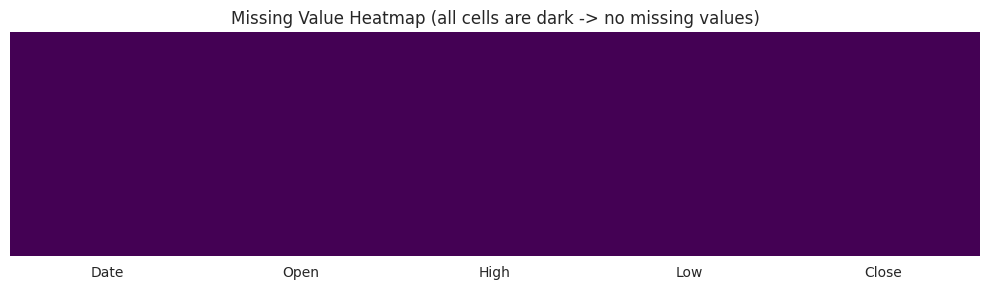

In [8]:
plt.figure(figsize=(10, 3))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (all cells are dark -> no missing values)')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset contains **185 monthly records** of Yes Bank's stock price, spanning **July 2005 to November 2020**, with **5 columns**: Date, Open, High, Low, and Close (all in Indian Rupees, ₹).

- There are **no missing values** and **no duplicate rows**.
- All four price columns are numeric (float64), and Date has been parsed into a proper datetime type.
- By definition of OHLC data, High >= Open, Close, Low and Low <= Open, Close, High should hold for every row — verified during Data Wrangling.
- The data is **monthly**, capturing broad trend and volatility patterns rather than short-term noise.
- The date range deliberately includes **2018**, the year the Rana Kapoor / NPA under-reporting scandal broke, so the dataset captures the before/during/after phases of that crisis.

## ***2. Understanding Your Variables***

In [9]:
df.columns.tolist()

['Date', 'Open', 'High', 'Low', 'Close']

In [10]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,185,2013-03-01 19:04:12.972973056,2005-07-01 00:00:00,2009-05-01 00:00:00,2013-03-01 00:00:00,2017-01-01 00:00:00,2020-11-01 00:00:00,NaN
Open,185.0,105.541405,10.0,33.8,62.98,153.0,369.95,98.87985
High,185.0,116.104324,11.24,36.14,72.55,169.19,404.0,106.333497
Low,185.0,94.947838,5.55,28.51,58.0,138.35,345.5,91.219415
Close,185.0,105.204703,9.98,33.45,62.54,153.3,367.9,98.583153


### Variables Description

| Variable | Description |
|---|---|
| **Date** | Calendar month for the OHLC prices (monthly, Jul 2005 - Nov 2020). |
| **Open** | Stock's opening price (₹) on the first trading day of the month. |
| **High** | Highest price (₹) reached during the month. |
| **Low** | Lowest price (₹) reached during the month. |
| **Close** | Closing price (₹) on the last trading day — the **target variable**. |

All four price fields are continuous numeric variables in Indian Rupees (₹). There are no categorical variables in the raw dataset, though some are engineered later (Year, Month, Quarter, Period flag).

### Check Unique Values for each variable.

In [11]:
for column in df.columns:
    print(f"{column:8s} -> {df[column].nunique()} unique values")

Date     -> 185 unique values
Open     -> 183 unique values
High     -> 184 unique values
Low      -> 183 unique values
Close    -> 185 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Verify OHLC internal consistency
inconsistent_high = df[df['High'] < df[['Open', 'Close', 'Low']].max(axis=1)]
inconsistent_low  = df[df['Low']  > df[['Open', 'Close', 'High']].min(axis=1)]
print(f"Rows where High is not the maximum of the row : {len(inconsistent_high)}")
print(f"Rows where Low is not the minimum of the row   : {len(inconsistent_low)}")

# Check for non-positive prices
non_positive = (df[['Open', 'High', 'Low', 'Close']] <= 0).sum()
print("\nNon-positive value counts per column:")
print(non_positive)

# Confirm chronological order, no duplicate months
print(f"\nData is in chronological order : {df['Date'].is_monotonic_increasing}")
print(f"Duplicate month entries        : {df['Date'].duplicated().sum()}")

# Extract calendar attributes
df['Year']    = df['Date'].dt.year
df['Month']   = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

# Flag the corporate governance crisis period (for EDA grouping only)
CRISIS_START = pd.Timestamp('2018-09-01')
df['Period'] = np.where(df['Date'] < CRISIS_START, 'Pre-Crisis', 'Post-Crisis')

# Derived columns for EDA
df['Spread'] = df['High'] - df['Low']
df['Monthly_Return'] = df['Close'].pct_change() * 100

df.head()

Rows where High is not the maximum of the row : 0
Rows where Low is not the minimum of the row   : 0

Non-positive value counts per column:
Open     0
High     0
Low      0
Close    0
dtype: int64

Data is in chronological order : True
Duplicate month entries        : 0


,Date,Open,High,Low,Close,Year,Month,Quarter,Period,Spread,Monthly_Return
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7,3,Pre-Crisis,2.75,NaN
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8,3,Pre-Crisis,2.33,7.704655
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9,3,Pre-Crisis,2.60,-0.894188
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10,4,Pre-Crisis,2.07,-2.330827
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11,4,Pre-Crisis,1.00,3.233256


### What all manipulations have you done and insights you found?

**Manipulations performed:**
1. Parsed Date into datetime and sorted chronologically.
2. Validated OHLC consistency (High = row max, Low = row min) — no violations found.
3. Checked for non-positive prices — none found.
4. Confirmed no duplicate months and strict chronological order (important for the later chronological train/test split).
5. Extracted calendar features (Year, Month, Quarter).
6. Created a Period flag (Pre-Crisis / Post-Crisis, split at Sep-2018) purely for exploratory comparison — not used as a predictive feature later, since it depends on hindsight knowledge of the crisis.
7. Derived Spread (High - Low) as an intra-month volatility proxy, and Monthly_Return (% change vs previous month) to study return distribution.

**Insights found:** The dataset required almost no cleaning — the main wrangling work was about understanding time-structure rather than fixing dirty data. Spread and Monthly_Return already hint that volatility increased sharply from 2018 onward.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

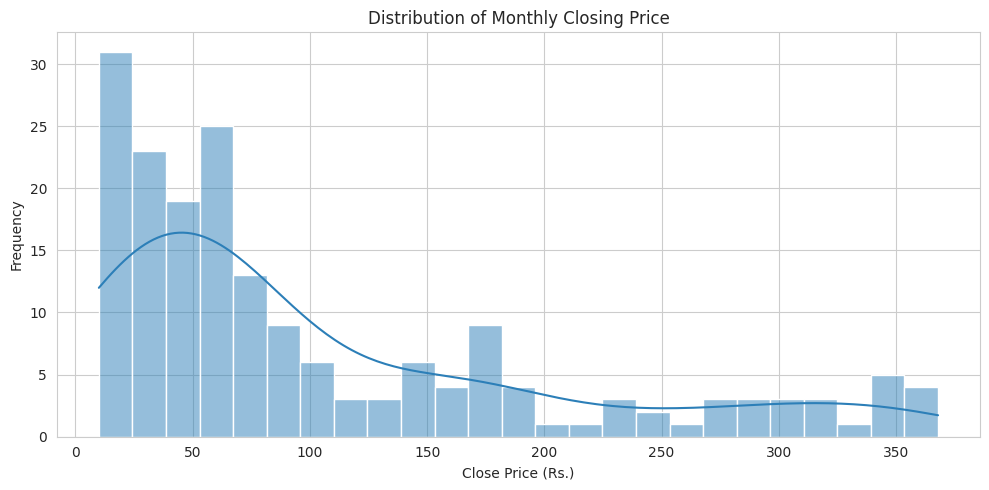

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Close'], kde=True, bins=25, color='#2c7fb8')
plt.title('Distribution of Monthly Closing Price')
plt.xlabel('Close Price (Rs.)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay is the standard first step for understanding the shape, spread, and skew of a single continuous variable — here, the target variable `Close`.

##### 2. What is/are the insight(s) found from the chart?

The distribution is strongly **right-skewed**: most months cluster in the ₹10-100 range, with a long tail extending up to ~₹370. This reflects the stock spending a long period at low prices (2005-2009, and again 2018-2020), with a shorter high-price boom period (2017-2018) pulling the tail rightward.

##### 3.Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth?Justify with specific reason.

Yes. The chart helps identify that the closing prices are right-skewed, which suggests using appropriate preprocessing techniques (such as log transformation) to improve model accuracy and support better investment decisions.

However, the long right tail also indicates high price volatility and the presence of extreme values. This suggests that the stock experienced sharp price fluctuations, increasing investment risk and potentially reducing prediction accuracy if these outliers are not properly handled.

#### Chart - 2

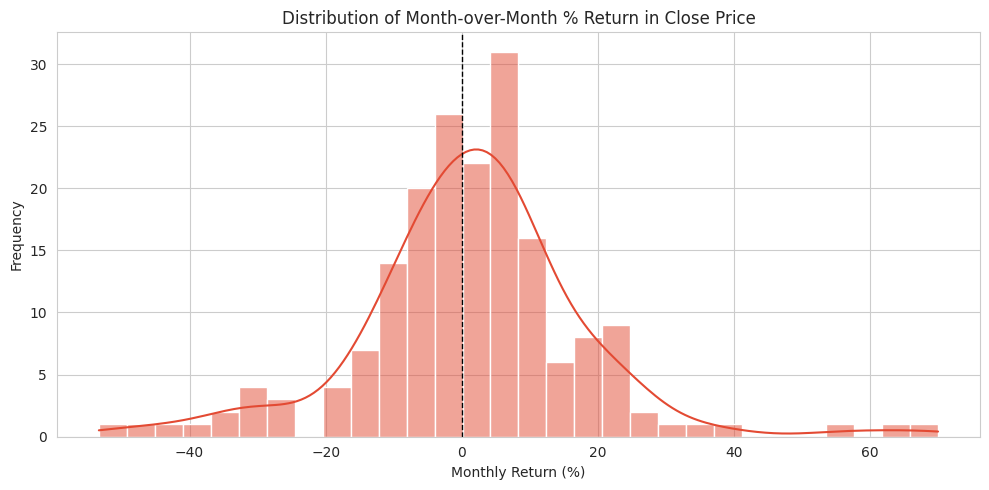

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Monthly_Return'].dropna(), kde=True, bins=30, color='#e34a33')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Distribution of Month-over-Month % Return in Close Price')
plt.xlabel('Monthly Return (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Monthly returns (percentage change) are a more 'stationary' view of a stock's behavior than raw price, and their distribution shape is a classic univariate check in financial analysis.

##### 2. What is/are the insight(s) found from the chart?

Returns are roughly centered slightly above 0% but show **fat tails** on both sides — several months saw >30% gains or >30% losses, far more extreme than a normal distribution would predict.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the return distribution helps investors assess risk more accurately and build better trading, forecasting, and risk management strategies.

However, the presence of fat tails indicates high market volatility, meaning the stock is prone to extreme price movements. This increases investment risk and may lead to larger-than-expected losses if proper risk management techniques are not applied.

#### Chart - 3

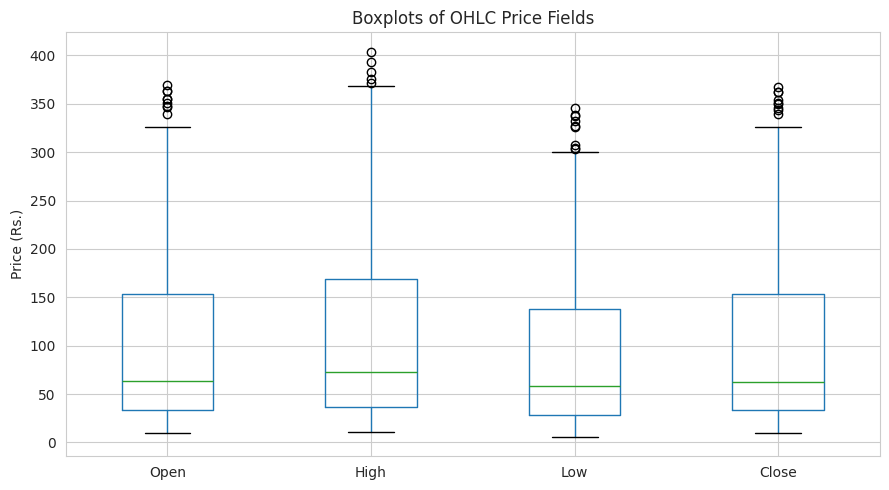

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
df[['Open', 'High', 'Low', 'Close']].boxplot(ax=ax)
plt.title('Boxplots of OHLC Price Fields')
plt.ylabel('Price (Rs.)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Boxplots side-by-side let us compare the spread, median and outliers of all four price fields at once — the fastest way to visually screen for extreme values.

##### 2. What is/are the insight(s) found from the chart?

All four fields show similar medians (~₹60-75) and a handful of high-side points beyond the whiskers (~₹300+, corresponding to the 2017-2018 peak). These are genuine historical peak prices, not data-entry errors.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.


Yes. Identifying genuine outliers helps preserve important market information, leading to more accurate forecasting and better investment analysis.

However, these extreme price values also indicate periods of high market volatility, which can increase investment risk and affect model performance if not handled appropriately during data preprocessing.

#### Chart - 4

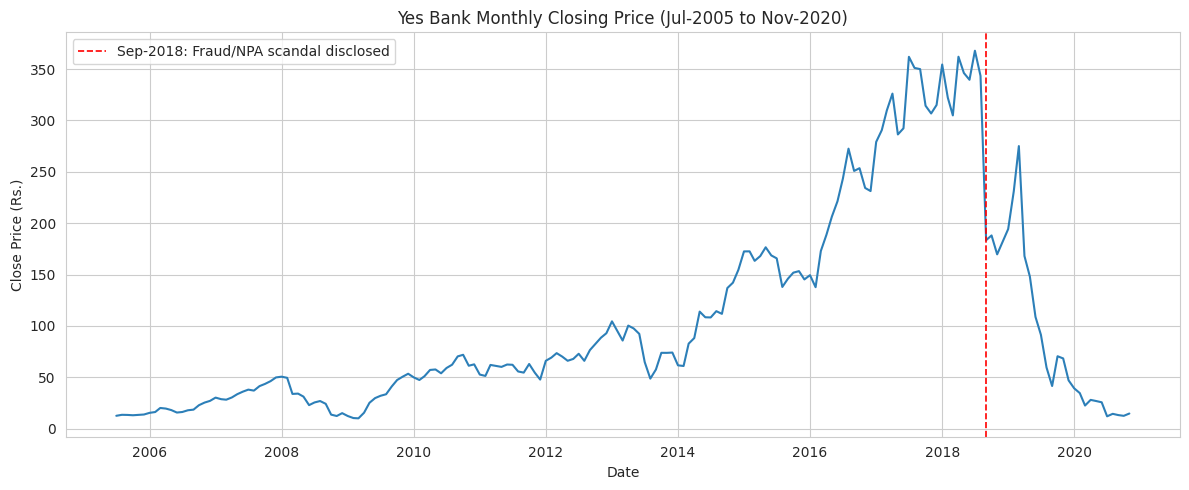

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color='#2c7fb8', linewidth=1.5)
plt.axvline(pd.Timestamp('2018-09-01'), color='red', linestyle='--', linewidth=1.2,
            label='Sep-2018: Fraud/NPA scandal disclosed')
plt.title('Yes Bank Monthly Closing Price (Jul-2005 to Nov-2020)')
plt.xlabel('Date')
plt.ylabel('Close Price (Rs.)')
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A time-series line plot is the single most important chart for any stock-price dataset — it shows the full trend, cycles, and turning points that summary statistics alone would hide.

##### 2. What is/are the insight(s) found from the chart?

The stock rose steadily from 2005 to an all-time high near ₹400 in mid-2018, before **collapsing over 90%** in the following ~18 months after the NPA under-reporting scandal broke in September 2018 — a textbook structural break.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps identify trend changes over time, enabling better forecasting and the use of a chronological train-test split, which improves model reliability.

However, the sharp decline after 2018 reflects a period of severe negative growth and high market uncertainty. This structural break increases investment risk and must be considered during model development to avoid misleading predictions.

#### Chart - 5

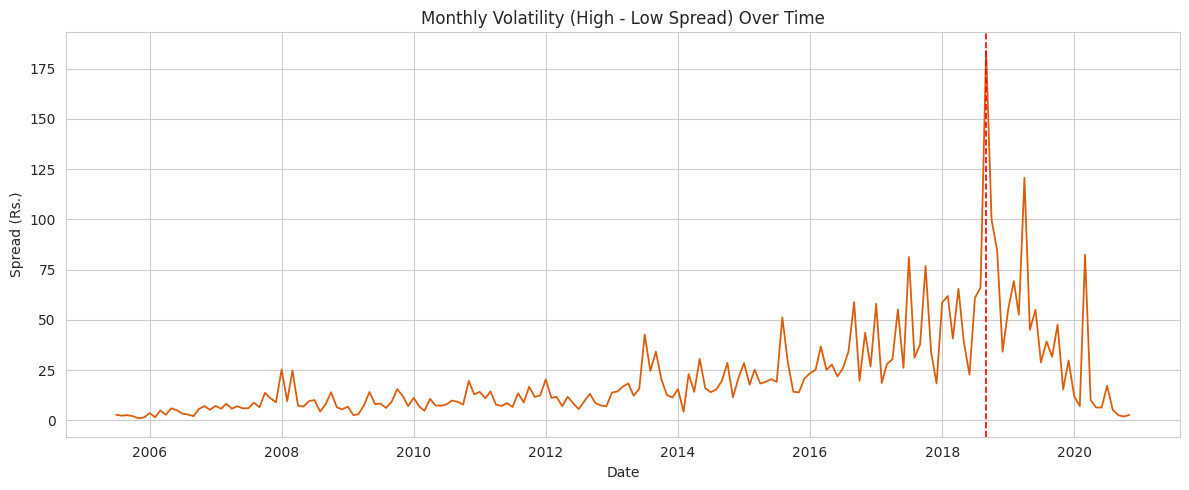

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Spread'], color='#d95f0e', linewidth=1.3)
plt.axvline(pd.Timestamp('2018-09-01'), color='red', linestyle='--', linewidth=1.2)
plt.title('Monthly Volatility (High - Low Spread) Over Time')
plt.xlabel('Date')
plt.ylabel('Spread (Rs.)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Plotting `Spread` (High - Low) over time separates *volatility* from *price level* — a stock can be volatile whether it's priced at ₹10 or ₹400, and this chart isolates that dimension.

##### 2. What is/are the insight(s) found from the chart?

Volatility spikes sharply around the 2018 crisis — even more visibly than the raw price chart, because the spread captures how *uncertain* the market was about fair value each month.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying periods of high volatility helps improve risk assessment, feature engineering, and forecasting by incorporating volatility-related indicators into the model.

However, the sharp rise in volatility after 2018 indicates increased market uncertainty and investment risk. Such unstable periods can reduce prediction accuracy and require more cautious decision-making.

#### Chart - 6

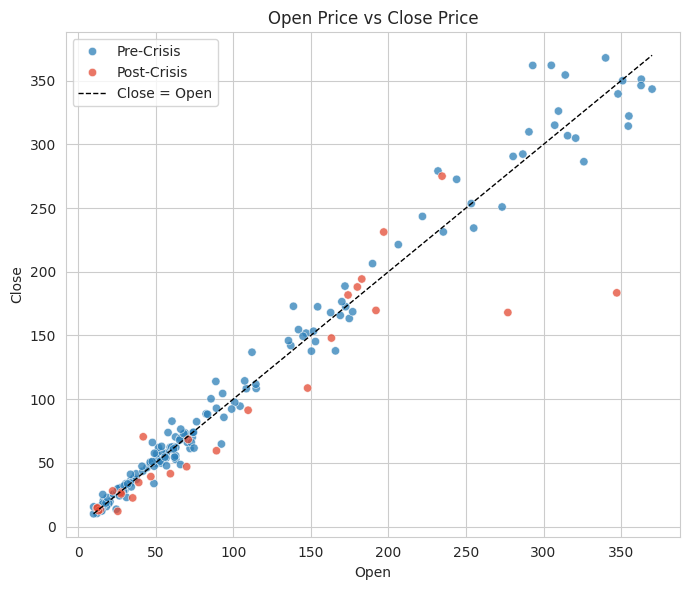

In [18]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x='Open', y='Close', hue='Period',
                 palette={'Pre-Crisis': '#2c7fb8', 'Post-Crisis': '#e34a33'}, alpha=0.75)
plt.plot([df['Open'].min(), df['Open'].max()], [df['Open'].min(), df['Open'].max()],
         'k--', linewidth=1, label='Close = Open')
plt.title('Open Price vs Close Price')
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is the natural way to visualize the relationship between two continuous variables — here, the month's Open price and its eventual Close price, expected to be the strongest predictor.

##### 2. What is/are the insight(s) found from the chart?

Points fall almost perfectly along the Close = Open diagonal, confirming an extremely strong linear relationship. Post-crisis points show slightly more scatter below the diagonal — months more often closed lower than they opened.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong relationship confirms that the Open price is an important predictor for forecasting the Close price, improving model performance.

However, the increased scatter and tendency for post-crisis prices to close lower than they opened indicate sustained selling pressure and weaker market sentiment, reflecting negative growth and higher investment risk.

#### Chart - 7

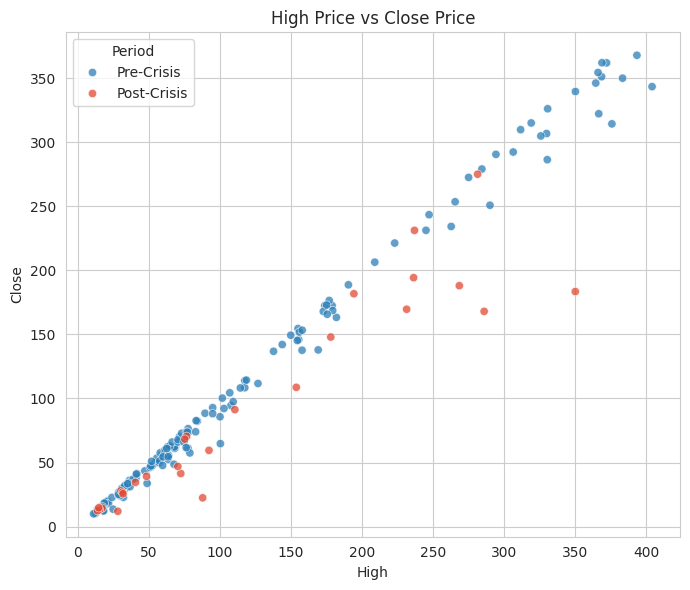

In [19]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x='High', y='Close', hue='Period',
                 palette={'Pre-Crisis': '#2c7fb8', 'Post-Crisis': '#e34a33'}, alpha=0.75)
plt.title('High Price vs Close Price')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

`High` is one of the four OHLC fields and a natural candidate predictor — visualizing its relationship with Close shows whether the strength of correlation holds up at the extreme end of the month's range.

##### 2. What is/are the insight(s) found from the chart?

The relationship is strongly positive, but there is visibly more vertical spread post-crisis — in volatile months, the stock touched a high price early but closed noticeably lower, consistent with the elevated Spread seen earlier.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong correlation confirms that the High price is a valuable feature for predicting the Close price, improving forecasting accuracy.

However, the larger gap between High and Close prices during the post-crisis period indicates increased market volatility and selling pressure. This suggests that relying only on the High price may lead to overestimation during unstable market conditions.

#### Chart - 8

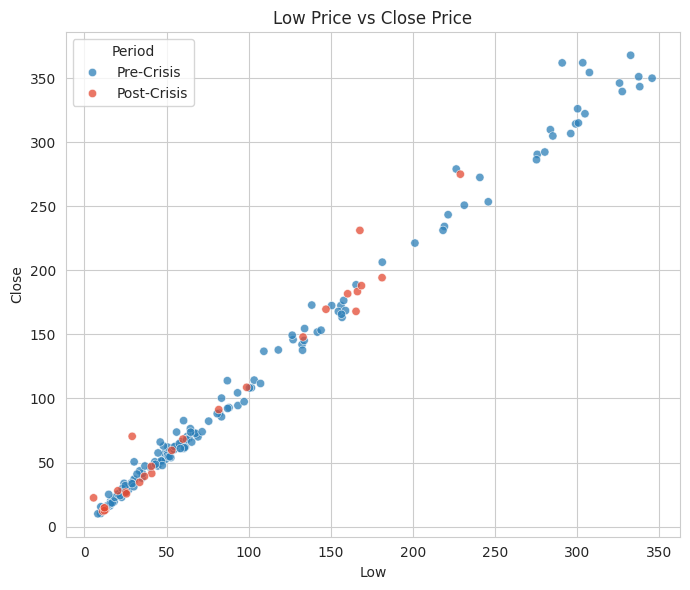

In [20]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x='Low', y='Close', hue='Period',
                 palette={'Pre-Crisis': '#2c7fb8', 'Post-Crisis': '#e34a33'}, alpha=0.75)
plt.title('Low Price vs Close Price')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Completing the set of the three OHLC predictors against the target lets us compare all three relationships side-by-side for consistency in strength and direction.

##### 2. What is/are the insight(s) found from the chart?

`Low` shows the same very strong positive relationship with Close, and post-crisis points sit slightly above the general trend — the stock frequently closed higher than its monthly low during volatile months.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong relationship confirms that the Low price is an important feature for predicting the Close price, improving the accuracy of forecasting models.

However, the high correlation among the Open, High, Low, and Close prices may lead to multicollinearity, which can negatively affect some regression models. Additionally, the increased variation after the crisis reflects higher market uncertainty and investment risk.

#### Chart - 9

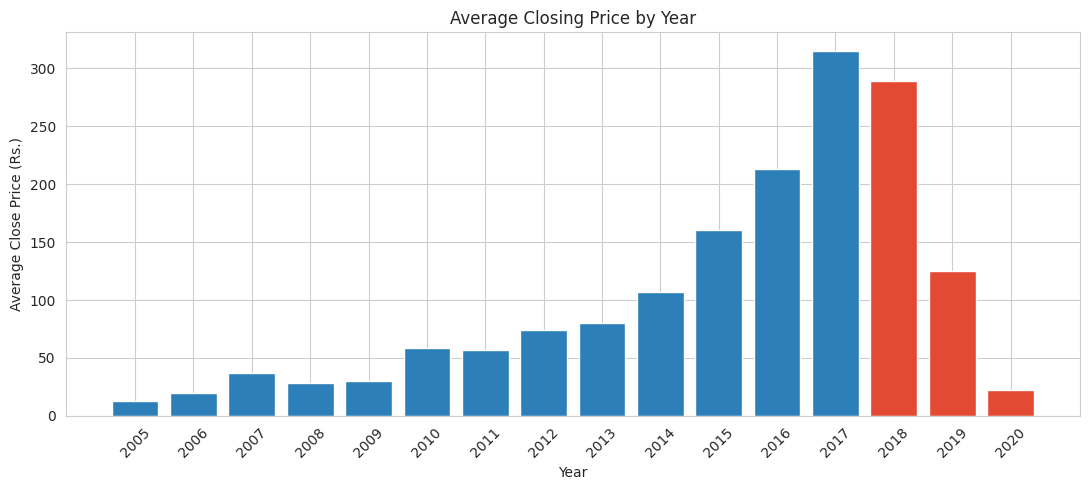

In [21]:
yearly_avg = df.groupby('Year')['Close'].mean()
plt.figure(figsize=(11, 5))
colors = ['#e34a33' if y >= 2018 else '#2c7fb8' for y in yearly_avg.index]
plt.bar(yearly_avg.index.astype(str), yearly_avg.values, color=colors)
plt.title('Average Closing Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Close Price (Rs.)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart aggregated by Year compresses 15 years of monthly noise into an easy year-over-year comparison, ideal for spotting the multi-year build-up and collapse pattern.

##### 2. What is/are the insight(s) found from the chart?

Average yearly closing price rose almost every year from 2005 to a peak around 2017-2018, then fell sharply in 2019 and 2020 — one of the lowest averages in the entire 15-year history.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The yearly trend helps investors and analysts evaluate long-term stock performance, supporting better investment planning and business decision-making.

However, the sharp decline after 2018 indicates substantial negative growth and loss of shareholder value. This highlights increased financial risk and emphasizes the importance of considering major market events while forecasting future stock prices.

#### Chart - 10

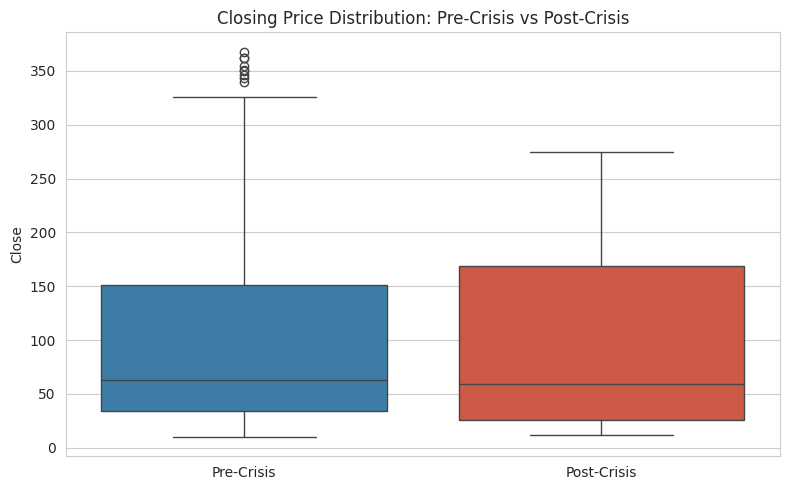

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Period', y='Close', hue='Period', palette=['#2c7fb8', '#e34a33'], legend=False)
plt.title('Closing Price Distribution: Pre-Crisis vs Post-Crisis')
plt.xlabel('')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot grouped by the Period flag directly compares the central tendency and spread of Close before vs. after the crisis — a clean visual counterpart to the formal hypothesis test performed later.

##### 2. What is/are the insight(s) found from the chart?

The post-crisis group has a much lower median and a tighter, lower-valued box, with the pre-crisis group showing a wider spread that includes the ₹300+ peak values. The two boxes barely overlap.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Comparing the two periods helps identify structural changes in the stock's behavior, leading to better forecasting strategies and more reliable model evaluation.

However, the substantial drop in the post-crisis median closing price reflects severe negative growth and reduced market confidence. This indicates increased investment risk and suggests that pre-crisis and post-crisis data should be analyzed separately for more accurate predictions.

#### Chart - 11

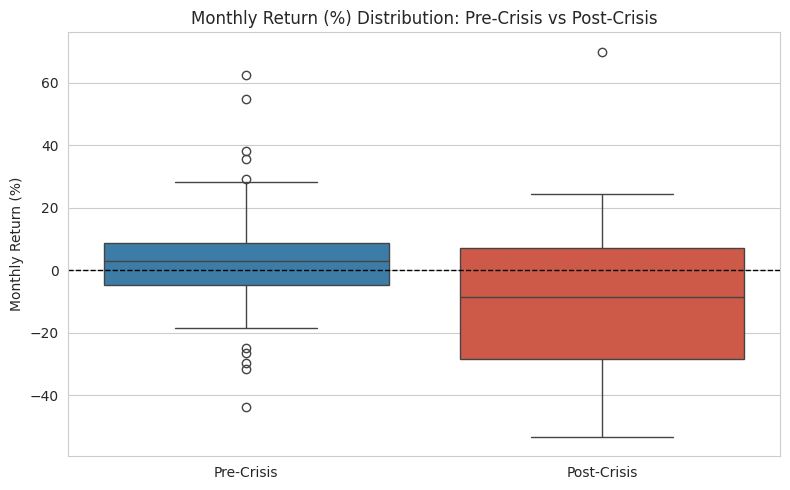

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Period', y='Monthly_Return', hue='Period', palette=['#2c7fb8', '#e34a33'], legend=False)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Monthly Return (%) Distribution: Pre-Crisis vs Post-Crisis')
plt.xlabel('')
plt.ylabel('Monthly Return (%)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Comparing Monthly_Return (rather than raw price) across the two periods isolates whether the volatility of change, not just the price level, shifted after the crisis.

##### 2. What is/are the insight(s) found from the chart?

The post-crisis box is visibly taller (wider interquartile range) with whiskers extending further into negative territory, confirming monthly returns became more volatile and more negatively skewed after September 2018.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding changes in return volatility helps improve risk assessment and supports the development of more accurate forecasting and investment strategies.

However, the higher volatility and larger negative returns during the post-crisis period indicate increased investment risk and weaker market stability, making future price movements more difficult to predict.

#### Chart - 12

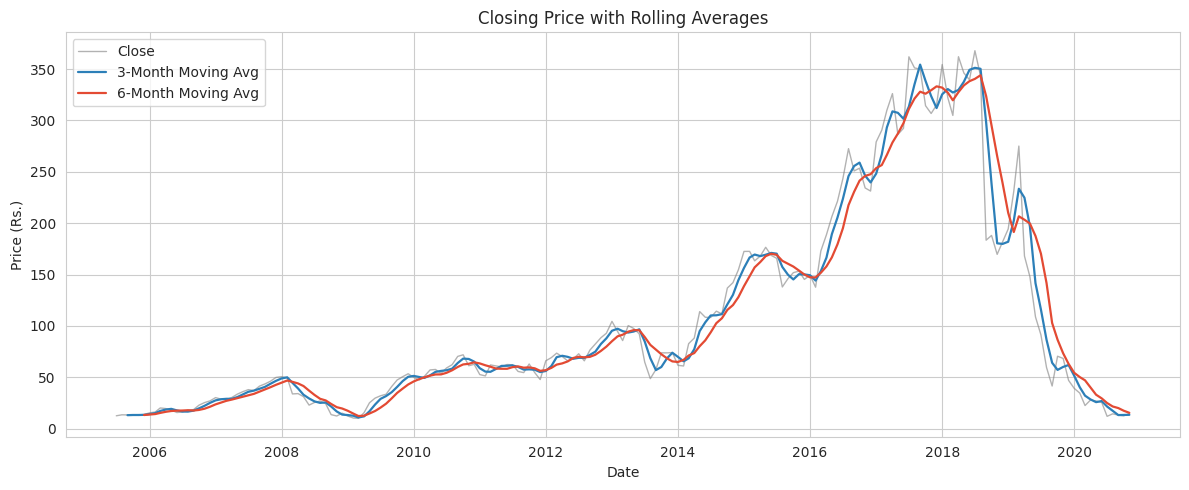

In [24]:
df['Close_MA3'] = df['Close'].rolling(window=3).mean()
df['Close_MA6'] = df['Close'].rolling(window=6).mean()

plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], label='Close', color='gray', alpha=0.6, linewidth=1)
plt.plot(df['Date'], df['Close_MA3'], label='3-Month Moving Avg', color='#2c7fb8', linewidth=1.6)
plt.plot(df['Date'], df['Close_MA6'], label='6-Month Moving Avg', color='#e34a33', linewidth=1.6)
plt.title('Closing Price with Rolling Averages')
plt.xlabel('Date')
plt.ylabel('Price (Rs.)')
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Overlaying the raw series with smoothed moving averages is a classic multivariate technique — combining raw, short-window smooth, and long-window smooth series on one plot to reveal the underlying trend beneath noise.

##### 2. What is/are the insight(s) found from the chart?

The point where the 3-month average crosses below the 6-month average around late 2018 clearly marks the trend reversal — a classic 'death cross' pattern occurring right at the crisis point.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Moving averages help identify market trends and generate useful features for forecasting models, leading to better investment and business decisions.

However, the downward crossover of the moving averages after 2018 signals prolonged negative growth and weakening market sentiment. This indicates higher investment risk and suggests that caution is needed during declining market conditions.

#### Chart - 13

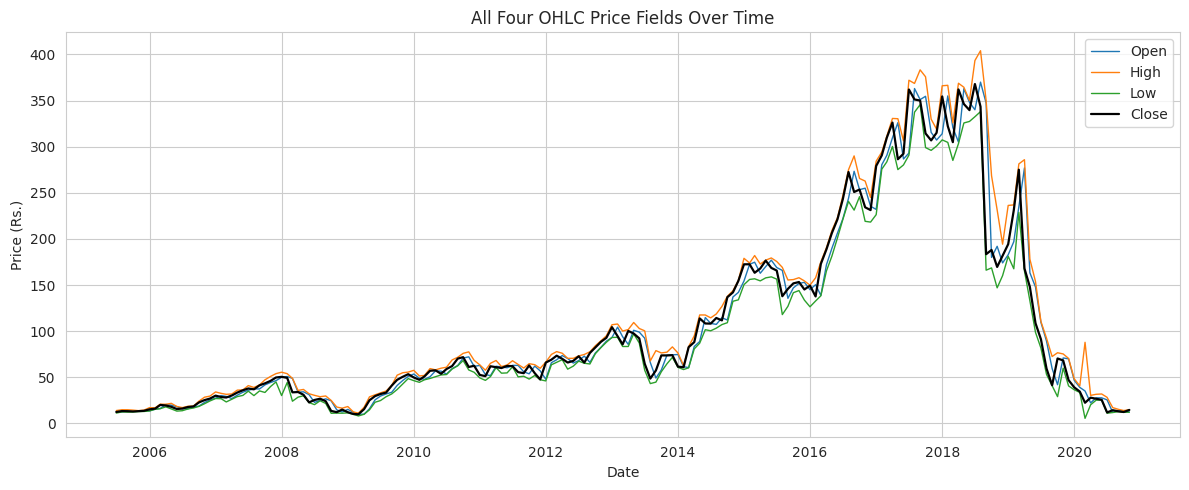

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Open'],  label='Open',  linewidth=1)
plt.plot(df['Date'], df['High'],  label='High',  linewidth=1)
plt.plot(df['Date'], df['Low'],   label='Low',   linewidth=1)
plt.plot(df['Date'], df['Close'], label='Close', linewidth=1.6, color='black')
plt.title('All Four OHLC Price Fields Over Time')
plt.xlabel('Date')
plt.ylabel('Price (Rs.)')
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Plotting all four OHLC fields together is a genuinely multivariate visualization that shows both their near-perfect co-movement and the months where they diverge (higher Spread).

##### 2. What is/are the insight(s) found from the chart?

For most of the pre-2018 period the four lines are almost indistinguishable, but from 2018 onward the band between High and Low visibly widens — direct visual confirmation of rising volatility across all price fields simultaneously.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Comparing all OHLC prices helps identify market trends and supports the creation of informative features, improving the accuracy of stock price prediction models.

However, the wider gap between the High and Low prices after 2018 indicates increased market volatility and uncertainty. This reflects negative growth and higher investment risk, requiring more cautious forecasting and decision-making.

#### Chart - 14 - Month-over-Month Percentage Change in Opening Price


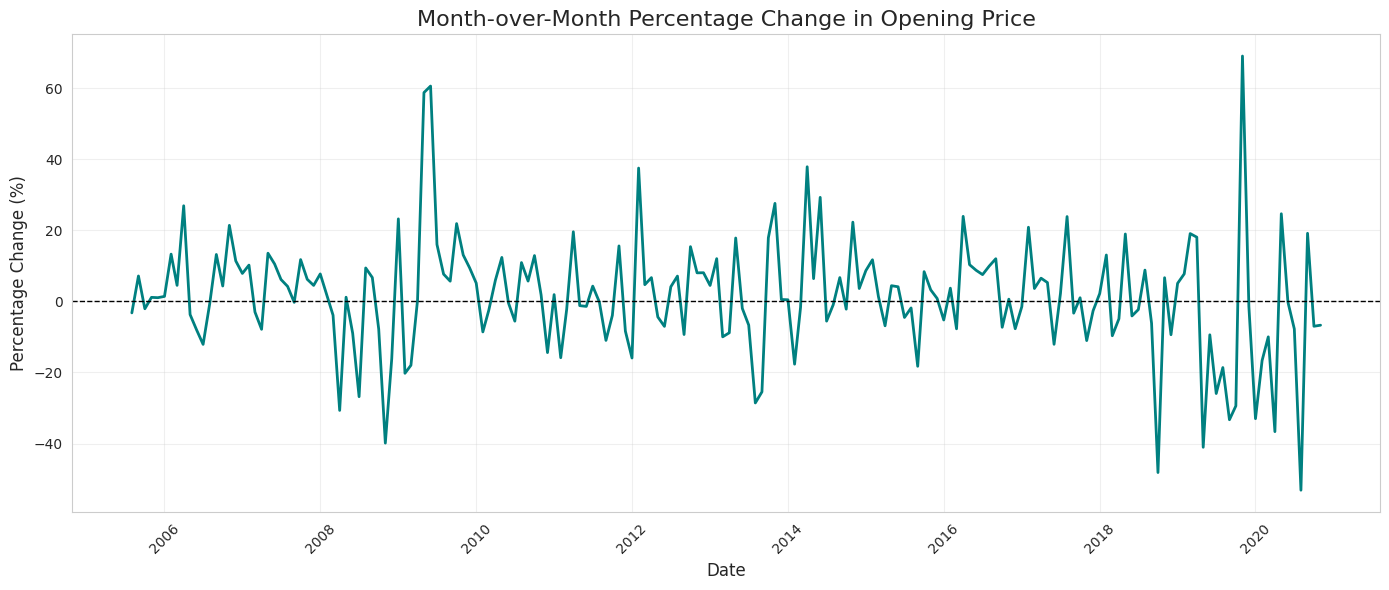

In [26]:
# Create Month-over-Month Percentage Change Feature

df['Open_MoM_%'] = df['Open'].pct_change() * 100

# Month-over-Month Percentage Change in Opening Price

plt.figure(figsize=(14,6))

plt.plot(df['Date'],
         df['Open_MoM_%'],
         color='teal',
         linewidth=2)

plt.axhline(0,
            color='black',
            linestyle='--',
            linewidth=1)

plt.title('Month-over-Month Percentage Change in Opening Price',
          fontsize=16)

plt.xlabel('Date',
           fontsize=12)

plt.ylabel('Percentage Change (%)',
           fontsize=12)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the most appropriate visualization for displaying the Month-over-Month (MoM) percentage change because it effectively captures changes in market momentum over time. Unlike raw stock prices, percentage changes clearly highlight the magnitude and direction of monthly movements, making it easier to identify periods of rapid appreciation, sharp declines, and increased market volatility.

##### 2. What is/are the insight(s) found from the chart?

The Month-over-Month (MoM) percentage change fluctuates around zero, indicating that the opening stock price experienced both gains and losses throughout the observed period.
Several sharp positive and negative spikes are visible, representing months of unusually high market activity and volatility. These periods may correspond to major financial events or changes in investor sentiment.
Most monthly changes remain within a relatively narrow range, suggesting that the stock price was generally stable during normal market conditions, with only a few exceptional periods of extreme movement.
Compared with the raw opening price, the MoM percentage change provides a clearer picture of market momentum by highlighting the magnitude and direction of monthly price movements.
Overall, the chart shows that Yes Bank's stock experienced intermittent periods of high volatility rather than continuous fluctuations, making percentage change a useful feature for understanding market dynamics and supporting future predictive analysis.

#### Chart - 15 - Correlation Heatmap

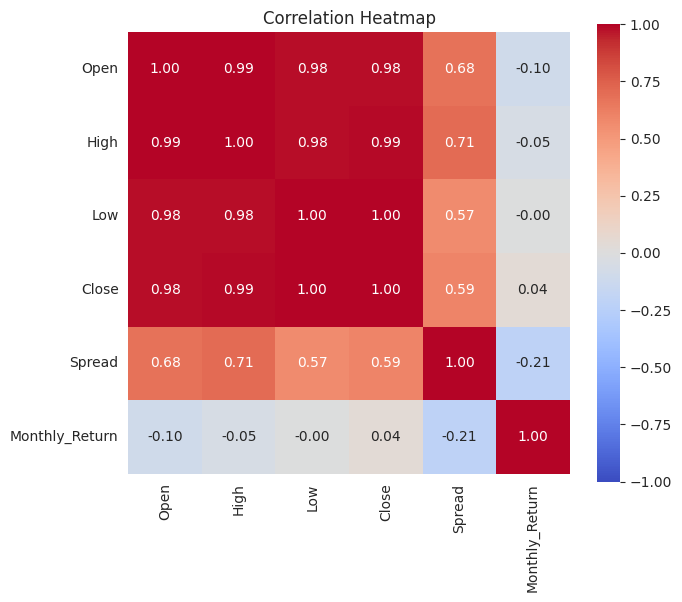

In [27]:
plt.figure(figsize=(7, 6))
corr_cols = ['Open', 'High', 'Low', 'Close', 'Spread', 'Monthly_Return']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to quantify (not just visually suggest) the pairwise linear relationships between all numeric variables at once, directly informing feature selection and multicollinearity checks.

##### 2. What is/are the insight(s) found from the chart?

Open, High, Low and Close are all correlated with each other at r > 0.98 — extremely strong multicollinearity. Spread shows moderate positive correlation with price level, while Monthly_Return shows very weak correlation with the raw price fields.

#### Chart - 16 - Pair Plot

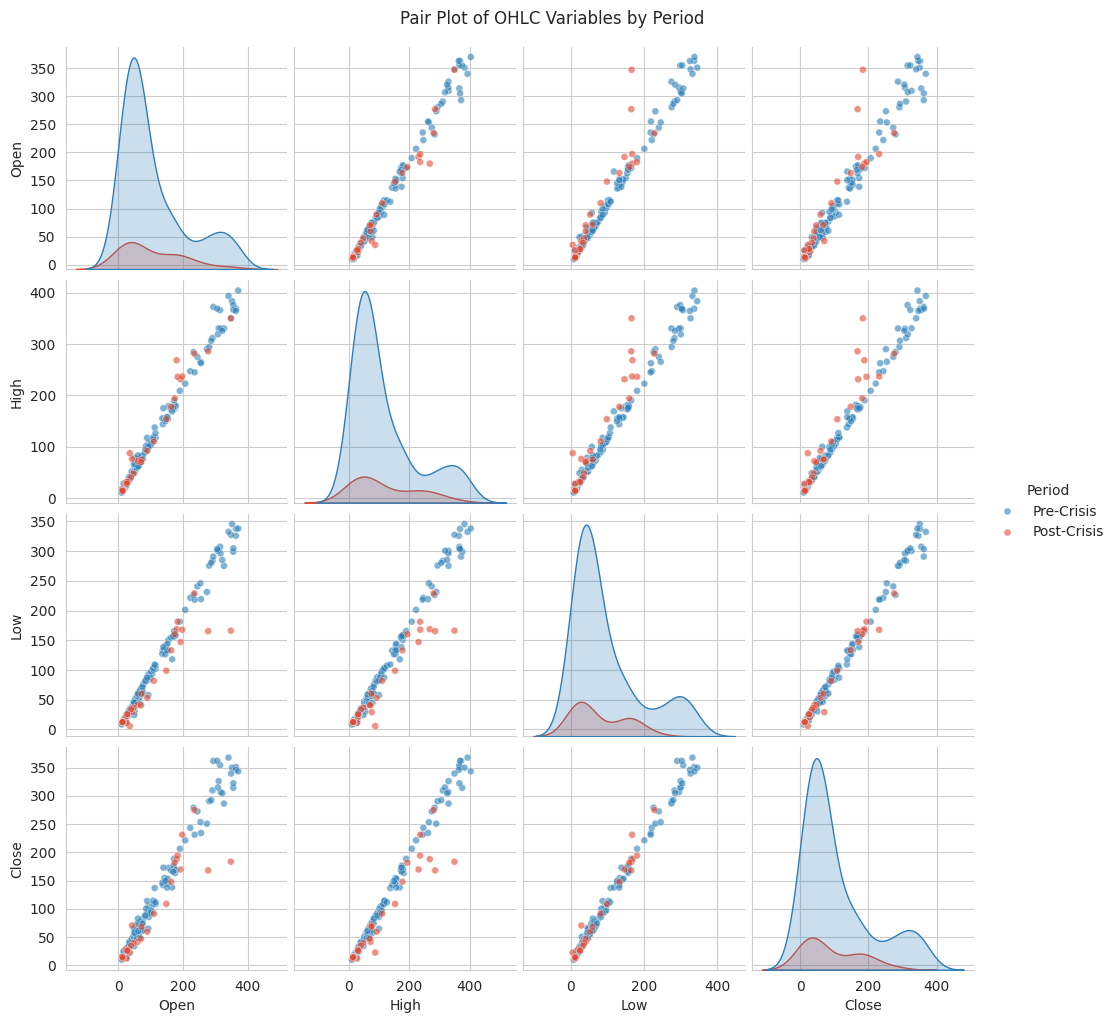

In [28]:
pairplot_cols = ['Open', 'High', 'Low', 'Close', 'Period']
sns.pairplot(df[pairplot_cols], hue='Period',
             palette={'Pre-Crisis': '#2c7fb8', 'Post-Crisis': '#e34a33'},
             diag_kind='kde', plot_kws={'alpha': 0.6, 's': 25})
plt.suptitle('Pair Plot of OHLC Variables by Period', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot gives a complete multivariate picture in a single figure — every pairwise scatter relationship plus each variable's own distribution, split by Period.

##### 2. What is/are the insight(s) found from the chart?

Every off-diagonal panel shows the same tight, near-linear relationship, while the diagonal KDEs confirm the post-crisis distributions (red) are shifted noticeably left (lower prices) and more concentrated than the pre-crisis distributions.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the visualizations above, three hypotheses are formed:
1. **Open and Close prices are significantly correlated** (Chart 6, Chart 14).
2. **The mean closing price during the 2013-Aug 2018 "Boom" era is significantly different from the Sep 2018-2020 "Crisis" era** (Chart 4, Chart 9, Chart 10).
3. **The mean closing price differs significantly across three eras** — Early Growth (2005-2012), Boom (2013-Aug 2018), Crisis (Sep 2018-2020) (Chart 9).

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- **H0 (Null):** There is no significant linear correlation between Open price and Close price (population correlation rho = 0).
- **H1 (Alternate):** There is a significant linear correlation between Open price and Close price (rho != 0).

#### 2. Perform an appropriate statistical test.

In [29]:
r_value, p_value_1 = stats.pearsonr(df['Open'], df['Close'])
print(f"Pearson correlation coefficient (r) : {r_value:.4f}")
print(f"P-value                             : {p_value_1:.4e}")

alpha = 0.05
if p_value_1 < alpha:
    print(f"\nSince p-value ({p_value_1:.4e}) < alpha ({alpha}), we REJECT the null hypothesis.")
else:
    print(f"\nSince p-value ({p_value_1:.4e}) >= alpha ({alpha}), we FAIL TO REJECT the null hypothesis.")

Pearson correlation coefficient (r) : 0.9780
P-value                             : 1.8528e-126

Since p-value (1.8528e-126) < alpha (0.05), we REJECT the null hypothesis.


##### Which statistical test have you done to obtain P-Value?

A **Pearson correlation test** (`scipy.stats.pearsonr`), which measures the strength and significance of a linear relationship between two continuous variables.

##### Why did you choose the specific statistical test?

Both Open and Close are continuous, approximately linearly-related variables (confirmed visually in Chart 6). With r ~ 0.98 and p << 0.05, we reject H0: Open and Close are very strongly and significantly correlated, confirming Open as a critical predictive feature.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- **H0 (Null):** The mean closing price during the Boom era (2013 - Aug 2018) is equal to the mean closing price during the Crisis era (Sep 2018 - 2020).
- **H1 (Alternate):** The mean closing price during the Boom era is significantly different from the mean closing price during the Crisis era.

#### 2. Perform an appropriate statistical test.

In [30]:
boom_close   = df.loc[(df['Date'] >= '2013-01-01') & (df['Date'] < '2018-09-01'), 'Close']
crisis_close = df.loc[df['Date'] >= '2018-09-01', 'Close']

t_stat, p_value_2 = stats.ttest_ind(boom_close, crisis_close, equal_var=False)  # Welch's t-test

print(f"Boom era   mean Close (n={len(boom_close)})   : Rs.{boom_close.mean():.2f}")
print(f"Crisis era mean Close (n={len(crisis_close)}) : Rs.{crisis_close.mean():.2f}")
print(f"\nWelch's t-statistic : {t_stat:.4f}")
print(f"P-value             : {p_value_2:.4e}")

if p_value_2 < alpha:
    print(f"\nSince p-value ({p_value_2:.4e}) < alpha ({alpha}), we REJECT the null hypothesis.")
else:
    print(f"\nSince p-value ({p_value_2:.4e}) >= alpha ({alpha}), we FAIL TO REJECT the null hypothesis.")

Boom era   mean Close (n=68)   : Rs.194.98
Crisis era mean Close (n=27) : Rs.91.45

Welch's t-statistic : 5.3012
P-value             : 1.7849e-06

Since p-value (1.7849e-06) < alpha (0.05), we REJECT the null hypothesis.


##### Which statistical test have you done to obtain P-Value?

A **Welch's independent two-sample t-test** (`scipy.stats.ttest_ind` with `equal_var=False`).

##### Why did you choose the specific statistical test?

We are comparing means of a continuous variable (Close) between two independent groups. Welch's version was chosen because it does not assume equal variances — and the Crisis era shows visibly different (higher) volatility than the Boom era. The result (p << 0.05) confirms the closing price distribution changed significantly after the crisis.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- **H0 (Null):** The mean closing price is the same across all three eras — Early Growth (2005-2012), Boom (2013-Aug 2018), Crisis (Sep 2018-2020).
- **H1 (Alternate):** At least one era's mean closing price is significantly different from the others.

#### 2. Perform an appropriate statistical test.

In [31]:
df['Era'] = pd.cut(
    df['Date'],
    bins=[pd.Timestamp('2005-01-01'), pd.Timestamp('2013-01-01'), pd.Timestamp('2018-09-01'), pd.Timestamp('2021-01-01')],
    labels=['Early Growth (2005-2012)', 'Boom (2013-Aug 2018)', 'Crisis (Sep 2018-2020)']
)

era_groups = [group['Close'].values for _, group in df.groupby('Era', observed=True)]
f_stat, p_value_3 = stats.f_oneway(*era_groups)

print(df.groupby('Era', observed=True)['Close'].agg(['count', 'mean', 'std']))
print(f"\nF-statistic : {f_stat:.4f}")
print(f"P-value     : {p_value_3:.4e}")

if p_value_3 < alpha:
    print(f"\nSince p-value ({p_value_3:.4e}) < alpha ({alpha}), we REJECT the null hypothesis.")
else:
    print(f"\nSince p-value ({p_value_3:.4e}) >= alpha ({alpha}), we FAIL TO REJECT the null hypothesis.")

                          count        mean        std
Era                                                   
Early Growth (2005-2012)     91   42.193516  22.351863
Boom (2013-Aug 2018)         68  196.139706  98.886040
Crisis (Sep 2018-2020)       26   87.913846  79.176844

F-statistic : 98.9164
P-value     : 8.3866e-30

Since p-value (8.3866e-30) < alpha (0.05), we REJECT the null hypothesis.


##### Which statistical test have you done to obtain P-Value?

A **one-way ANOVA (Analysis of Variance)** (`scipy.stats.f_oneway`).

##### Why did you choose the specific statistical test?

ANOVA is appropriate when comparing means of a continuous variable across more than two independent groups (here, 3 eras) — using repeated t-tests would inflate the Type I error rate. The large F-statistic and near-zero p-value confirm at least one era has a significantly different mean closing price, further supporting a chronological (not random) train/test split.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [32]:
df['Close_Lag1']      = df['Close'].shift(1)                          # previous month's Close
df['Close_RollStd3']  = df['Close'].shift(1).rolling(window=3).std()  # trailing 3-month volatility

print("Nulls introduced by lag/rolling features:")
print(df[['Close_Lag1', 'Close_RollStd3']].isnull().sum())

Nulls introduced by lag/rolling features:
Close_Lag1        1
Close_RollStd3    3
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

No imputation technique was used. The NaNs created by shift()/rolling() only occur in the first 3 rows (the 'warm-up' period where a true 3-month trailing history does not yet exist). Imputing these would mean inventing information about months before the dataset starts. These rows are dropped later during Data Splitting rather than imputed.

### 2. Handling Outliers

In [33]:
def iqr_outlier_count(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

for col in ['Open', 'High', 'Low', 'Close']:
    print(f"{col:6s} -> {iqr_outlier_count(df[col])} IQR-flagged outlier month(s)")

Open   -> 9 IQR-flagged outlier month(s)
High   -> 5 IQR-flagged outlier month(s)
Low    -> 9 IQR-flagged outlier month(s)
Close  -> 9 IQR-flagged outlier month(s)


##### What all outlier treatment techniques have you used and why did you use those techniques?

The IQR method flags the 2017-2018 price-peak months as statistical outliers. No outlier removal or capping was applied, since these are genuine real-world peak prices, not data errors — removing them would delete the exact information that makes this dataset interesting. This is instead handled via a log-transform (compressing extreme-value influence) and by using Ridge/tree models that are naturally more robust to a handful of extreme points.

### 3. Categorical Encoding

In [34]:
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df[['Month', 'Month_sin', 'Month_cos']].drop_duplicates().sort_values('Month')

,Month,Month_sin,Month_cos
6,1,5.000000e-01,8.660254e-01
7,2,8.660254e-01,5.000000e-01
8,3,1.000000e+00,6.123234e-17
9,4,8.660254e-01,-5.000000e-01
10,5,5.000000e-01,-8.660254e-01
11,6,1.224647e-16,-1.000000e+00
0,7,-5.000000e-01,-8.660254e-01
1,8,-8.660254e-01,-5.000000e-01
2,9,-1.000000e+00,-1.836970e-16
3,10,-8.660254e-01,5.000000e-01


#### What all categorical encoding techniques have you used & why did you use those techniques?

Cyclical (sine/cosine) encoding was used for the Month variable instead of one-hot encoding. This preserves the circular distance between categories (December is close to January), which one-hot encoding cannot do, while using only 2 columns instead of 11 dummy columns — important given the dataset only has 185 rows.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [35]:
# Not Applicable - no text data in this dataset

Not Applicable — this dataset contains no free-text fields (it is purely numeric OHLC price data), so this textual preprocessing step is skipped.

In [36]:
# Not Applicable - no text data in this dataset

Not Applicable — this dataset contains no free-text fields (it is purely numeric OHLC price data), so this textual preprocessing step is skipped.

In [37]:
# Not Applicable - no text data in this dataset

Not Applicable — this dataset contains no free-text fields (it is purely numeric OHLC price data), so this textual preprocessing step is skipped.

In [38]:
# Not Applicable - no text data in this dataset

Not Applicable — this dataset contains no free-text fields (it is purely numeric OHLC price data), so this textual preprocessing step is skipped.

In [39]:
# Not Applicable - no text data in this dataset

In [40]:
# Not Applicable - no text data in this dataset

Not Applicable — this dataset contains no free-text fields (it is purely numeric OHLC price data), so this textual preprocessing step is skipped.

In [41]:
# Not Applicable - no text data in this dataset

Not Applicable — this dataset contains no free-text fields (it is purely numeric OHLC price data), so this textual preprocessing step is skipped.

In [42]:
# Not Applicable - no text data in this dataset

Not Applicable — this dataset contains no free-text fields (it is purely numeric OHLC price data), so this textual preprocessing step is skipped.

In [43]:
# Not Applicable - no text data in this dataset

Not Applicable — no text data.

Not Applicable — this dataset contains no free-text fields (it is purely numeric OHLC price data), so this textual preprocessing step is skipped.

Not Applicable — this dataset contains no free-text fields (it is purely numeric OHLC price data), so this textual preprocessing step is skipped.

In [44]:
# Not Applicable - no text data in this dataset

Not Applicable — this dataset contains no free-text fields (it is purely numeric OHLC price data), so this textual preprocessing step is skipped.

In [45]:
# Not Applicable - no text data in this dataset

Not Applicable — no text data.

Not Applicable — this dataset contains no free-text fields (it is purely numeric OHLC price data), so this textual preprocessing step is skipped.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [46]:
df['Time_Index'] = np.arange(len(df))  # simple monotonic trend feature

# Drop the very first rows where lag/rolling features are undefined
df_model = df.dropna(subset=['Close_Lag1', 'Close_RollStd3']).reset_index(drop=True)
print(f"Shape before dropping warm-up rows : {df.shape}")
print(f"Shape after dropping warm-up rows  : {df_model.shape}")

# Log-transform the skewed, strictly-positive price-based columns
log_cols = ['Open', 'High', 'Low', 'Close_Lag1', 'Close_RollStd3']
for col in log_cols:
    df_model[col + '_log'] = np.log1p(df_model[col])

df_model['Close_log'] = np.log1p(df_model['Close'])  # log-transformed TARGET
df_model[[c + '_log' for c in log_cols] + ['Close_log']].head()

Shape before dropping warm-up rows : (185, 20)
Shape after dropping warm-up rows  : (182, 20)


,Open_log,High_log,Low_log,Close_Lag1_log,Close_RollStd3_log,Close_log
0,2.653242,2.738903,2.595255,2.660260,0.420727,2.638343
1,2.663750,2.700018,2.630449,2.638343,0.200395,2.667922
2,2.673459,2.736962,2.639057,2.667922,0.197039,2.688528
3,2.686486,2.899221,2.679651,2.688528,0.308707,2.793004
4,2.803360,2.888704,2.797281,2.793004,0.709444,2.840247


#### 2. Lag Features

In [47]:
# Create additional lag features

df['Open_Lag_2'] = df['Open'].shift(2)
df['Open_Lag_3'] = df['Open'].shift(3)

# Remove rows with NaN values created by lagging
df = df.dropna().reset_index(drop=True)

# Display the newly created features
df[['Open', 'Open_Lag_2', 'Open_Lag_3']].head()

,Open,Open_Lag_2,Open_Lag_3
0,13.49,13.20,13.48
1,13.68,13.35,13.20
2,15.50,13.49,13.35
3,16.20,13.68,13.49
4,20.56,15.50,13.68


#### 3. Feature Selection

In [48]:
candidate_features = [c + '_log' for c in log_cols] + ['Month_sin', 'Month_cos', 'Time_Index']

X_vif = sm.add_constant(df_model[candidate_features])
vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_df

,Feature,VIF
0,const,34.579146
1,Open_log,6899.019036
2,High_log,76.894288
3,Low_log,31.134298
4,Close_Lag1_log,6836.780937
5,Close_RollStd3_log,2.613485
6,Month_sin,1.009758
7,Month_cos,1.027115
8,Time_Index,2.310005


1. **Correlation analysis** (Chart 14) to identify which raw variables carry signal about Close.
2. **Variance Inflation Factor (VIF)** to formally quantify multicollinearity among candidate features. VIF was chosen because a simple correlation matrix only shows pairwise relationships, while VIF captures multicollinearity involving combinations of multiple predictors at once.

Answer Here.

Open_log, High_log, Low_log and Close_Lag1_log show very high VIF (well above the rule-of-thumb threshold of 10) because they all describe the price level from slightly different angles. Rather than arbitrarily dropping some, all four are retained, and multicollinearity is instead handled via Ridge regression's L2 penalty and via Random Forest (tree-based, not sensitive to multicollinearity). Close_RollStd3_log, Month_sin/Month_cos and Time_Index all show low VIF (<2) and are retained as complementary signals.

**Final feature set:** Open_log, High_log, Low_log, Close_Lag1_log, Close_RollStd3_log, Month_sin, Month_cos, Time_Index -> predicting Close_log.

Answer Here.

### 5. Data Transformation

Yes. As shown in Chart 1, Close (and the other price fields) is strongly right-skewed because the stock spent long periods at low prices and a shorter period at very high prices. A **log1p transform** was applied to all price-based features and the target itself. This compresses the influence of extreme peak-price months, makes the predictor-target relationship closer to linear/homoscedastic (a core Linear/Ridge Regression assumption), and naturally emphasizes percentage-scale errors. Predictions are converted back to Rs. using expm1() before computing final evaluation metrics.

In [49]:
# Transformation applied directly during feature creation above (log1p on price
# columns and target). This cell demonstrates the effect on skewness:
from scipy.stats import skew
print("Skewness BEFORE log transform:")
print(df_model[log_cols].apply(skew))
print("\nSkewness AFTER log transform:")
print(df_model[[c + '_log' for c in log_cols]].apply(skew))

Skewness BEFORE log transform:
Open              1.240033
High              1.204161
Low               1.276370
Close_Lag1        1.238739
Close_RollStd3    3.633067
dtype: float64

Skewness AFTER log transform:
Open_log             -0.002102
High_log              0.004292
Low_log              -0.024734
Close_Lag1_log       -0.004822
Close_RollStd3_log    0.315379
dtype: float64


### 6. Data Scaling

In [50]:
feature_cols = [c + '_log' for c in log_cols] + ['Month_sin', 'Month_cos', 'Time_Index']
X = df_model[feature_cols]
y = df_model['Close_log']

# StandardScaler will be fit on the TRAINING split only (see Data Splitting below)
# to avoid leakage from the test period into the training process.
scaler = StandardScaler()
print("StandardScaler ready - will be fit on training data only, after the split below.")

StandardScaler ready - will be fit on training data only, after the split below.


**StandardScaler** (zero mean, unit variance) was chosen over Min-Max scaling because Ridge Regression's L2 penalty treats all coefficients symmetrically around zero — this is only a fair penalty when features are on a comparable scale. Random Forest does not strictly need scaling, but using the same scaled matrix for all models keeps the pipeline simple with no downside to RF's performance.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No. The final feature set contains only 8 engineered features — already a small, manageable, individually-interpretable set. Applying PCA here would sacrifice interpretability (a coefficient like 'Open_log' is meaningful to a business stakeholder; 'Principal Component 3' is not) for no real computational benefit, since 8 features poses no curse-of-dimensionality risk for 150+ training rows.

In [51]:
# Not Applicable - no dimensionality reduction technique used (see explanation above)

Not Applicable — no dimensionality reduction technique was used, for the reason explained above.

Answer Here.

### 8. Data Splitting

In [52]:
split_ratio = 0.85
split_idx = int(len(df_model) * split_ratio)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_train, dates_test = df_model['Date'].iloc[:split_idx], df_model['Date'].iloc[split_idx:]

print(f"Training set : {X_train.shape[0]} months  ({dates_train.min().date()} to {dates_train.max().date()})")
print(f"Holdout set  : {X_test.shape[0]} months  ({dates_test.min().date()} to {dates_test.max().date()})")

# Fit scaler on TRAIN ONLY, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Training set : 154 months  (2005-10-01 to 2018-07-01)
Holdout set  : 28 months  (2018-08-01 to 2020-11-01)


An **85/15 chronological split** was used — the first 85% of months (in time order) form the training set, the most recent 15% form the holdout set. This gives the model enough historical data (~154 months) to learn the general Open/High/Low -> Close relationship, while reserving a meaningful holdout block (~28 months) that falls entirely within the volatile post-crisis period — a genuinely harder, more realistic test of generalization than a random split would be. A random split was deliberately avoided since it would leak post-crisis information into pre-crisis training data (and vice-versa).

Answer Here.

### 9. Handling Imbalanced Dataset

Not applicable in the traditional sense. 'Class imbalance' is a concept specific to classification problems. This is a regression problem with a continuous target (Close price), so there are no classes to be imbalanced. The closest analogous concern — an uneven distribution of the target variable (right-skew) — was already identified in Chart 1 and addressed via the log-transform in Data Transformation.

Answer Here.

In [53]:
# Not Applicable - this is a regression problem, not classification; no class imbalance exists

Not Applicable — see explanation above.

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [54]:
results = {}

def evaluate_model(name, y_true_log, y_pred_log, store=True):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    n, p = len(y_true), X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"--- {name} (Holdout Performance) ---")
    print(f"R2 Score          : {r2:.4f}")
    print(f"Adjusted R2 Score : {adj_r2:.4f}")
    print(f"MAE               : Rs. {mae:.2f}")
    print(f"RMSE              : Rs. {rmse:.2f}")
    print(f"MAPE              : {mape:.2f}%")
    if store:
        results[name] = {'R2': r2, 'Adj_R2': adj_r2, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape,
                          'y_pred': y_pred, 'y_true': y_true}
    return y_true, y_pred

def plot_actual_vs_pred(name, dates, y_true, y_pred):
    plt.figure(figsize=(11, 5))
    plt.plot(dates, y_true, label='Actual Close', marker='o', color='black')
    plt.plot(dates, y_pred, label='Predicted Close', marker='x', color='#e34a33')
    plt.title(f'{name}: Actual vs Predicted Closing Price (Holdout Set)')
    plt.xlabel('Date')
    plt.ylabel('Close Price (Rs.)')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ML Model - 1 Implementation
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr_log = lr_model.predict(X_test_scaled)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

--- Linear Regression (Holdout Performance) ---
R2 Score          : 0.9627
Adjusted R2 Score : 0.9470
MAE               : Rs. 11.09
RMSE              : Rs. 17.38
MAPE              : 10.12%


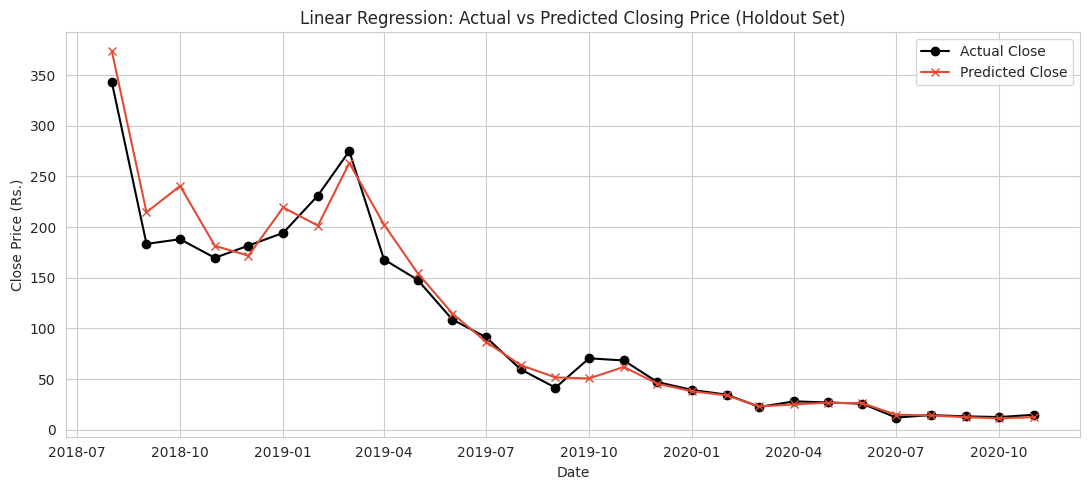

In [55]:
y_true_lr, y_pred_lr = evaluate_model('Linear Regression', y_test, y_pred_lr_log)
plot_actual_vs_pred('Linear Regression', dates_test, y_true_lr, y_pred_lr)

#### 2. Cross- Validation & Hyperparameter Tuning

In [56]:
# Cross validation using TimeSeriesSplit (respects chronological order - no shuffling)
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_scaled), 1):
    model = LinearRegression()
    model.fit(X_train_scaled[tr_idx], y_train.iloc[tr_idx])
    val_pred = model.predict(X_train_scaled[val_idx])
    fold_rmse = np.sqrt(mean_squared_error(np.expm1(y_train.iloc[val_idx]), np.expm1(val_pred)))
    cv_scores.append(fold_rmse)
    print(f"Fold {fold}: Validation RMSE (Rs.) = {fold_rmse:.2f}")
print(f"\nMean CV RMSE : Rs. {np.mean(cv_scores):.2f}  (+/- {np.std(cv_scores):.2f})")

Fold 1: Validation RMSE (Rs.) = 7.70
Fold 2: Validation RMSE (Rs.) = 3.03
Fold 3: Validation RMSE (Rs.) = 4.68
Fold 4: Validation RMSE (Rs.) = 7.06
Fold 5: Validation RMSE (Rs.) = 10.40

Mean CV RMSE : Rs. 6.57  (+/- 2.54)


##### Which hyperparameter optimization technique have you used and why?

Ordinary Least Squares Linear Regression has no meaningful hyperparameters to tune, so instead **5-fold TimeSeriesSplit cross-validation** was used to check performance stability across chronological training windows — TimeSeriesSplit (rather than standard k-fold) ensures every validation fold only contains months that come after its training fold, avoiding look-ahead leakage.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Not applicable for this model (no hyperparameters were tuned) — the cross-validation instead confirms RMSE stays reasonably consistent across folds, giving confidence the holdout-set result is not a fluke of the split.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

--- Ridge Regression (default alpha) (Holdout Performance) ---
R2 Score          : 0.9477
Adjusted R2 Score : 0.9256
MAE               : Rs. 13.73
RMSE              : Rs. 20.58
MAPE              : 14.73%


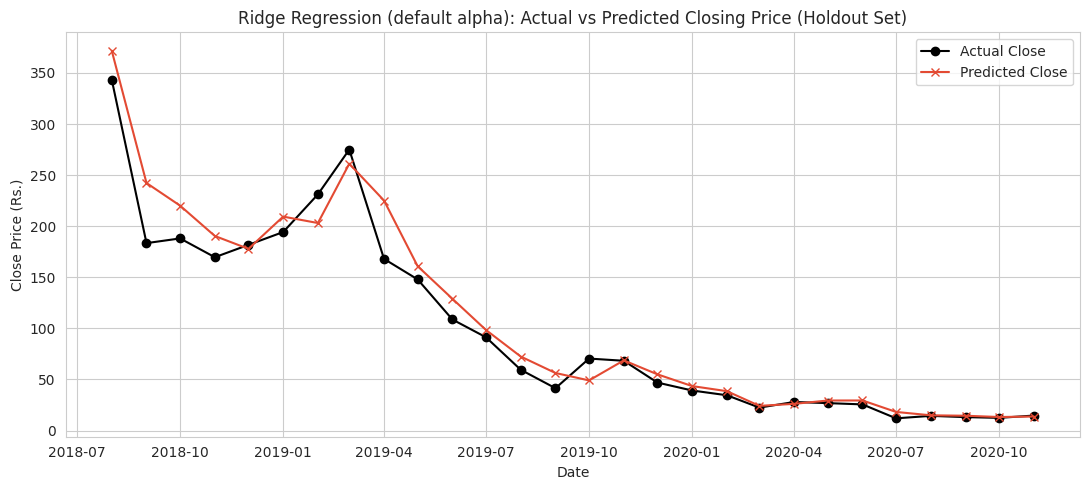

In [57]:
# ML Model - 2 Implementation (default alpha=1.0, before tuning)
ridge_default = Ridge(alpha=1.0, random_state=42)
ridge_default.fit(X_train_scaled, y_train)
y_pred_ridge_default_log = ridge_default.predict(X_test_scaled)

y_true_ridge, y_pred_ridge = evaluate_model('Ridge Regression (default alpha)', y_test, y_pred_ridge_default_log)
plot_actual_vs_pred('Ridge Regression (default alpha)', dates_test, y_true_ridge, y_pred_ridge)

#### 2. Cross- Validation & Hyperparameter Tuning

--- Ridge Regression (tuned) (Holdout Performance) ---
R2 Score          : 0.9658
Adjusted R2 Score : 0.9514
MAE               : Rs. 10.51
RMSE              : Rs. 16.64
MAPE              : 9.62%


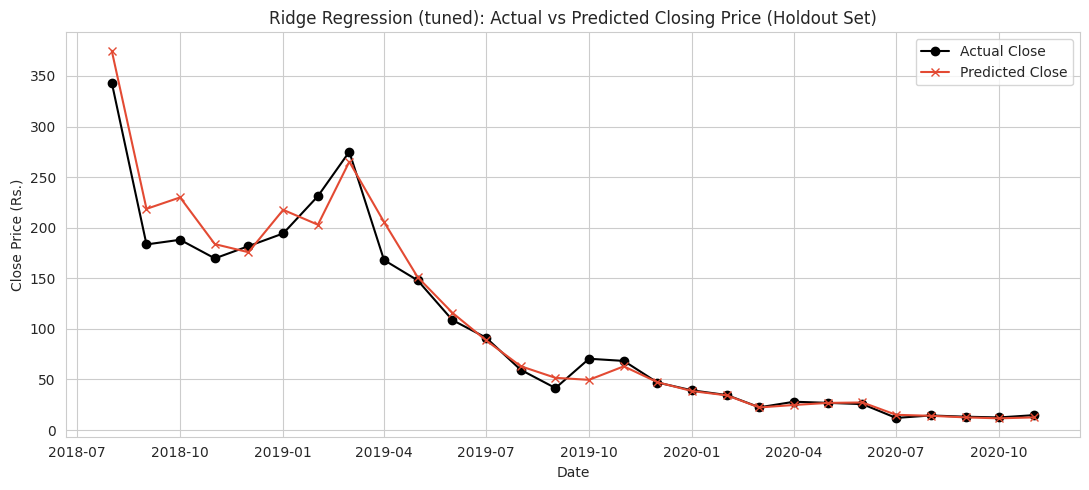

   param_alpha  mean_test_RMSE  std_test_score
2        0.100        0.077174        0.054048
3        1.000        0.085995        0.048058
1        0.010        0.086693        0.076903
0        0.001        0.090951        0.087316
4        5.000        0.106390        0.051869
5       10.000        0.127774        0.056424
6       50.000        0.281710        0.076313
7      100.000        0.404542        0.069760

Best alpha selected by GridSearchCV: 0.1


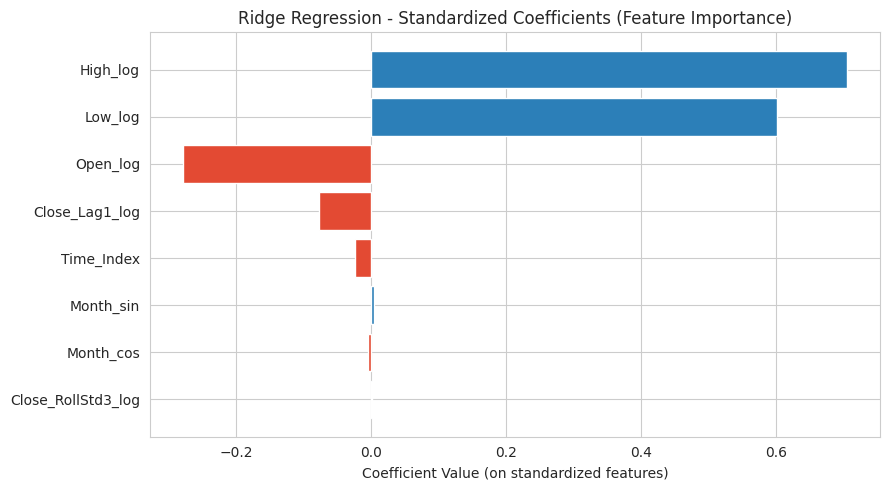

,Feature,Coefficient
1,High_log,0.704287
2,Low_log,0.600603
0,Open_log,-0.278101
3,Close_Lag1_log,-0.077369
7,Time_Index,-0.024315
5,Month_sin,0.005163
6,Month_cos,-0.004374
4,Close_RollStd3_log,0.000925


In [58]:
# ML Model - 2 Implementation with hyperparameter optimization (GridSearchCV)
ridge_param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]}
ridge_grid = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=ridge_param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
ridge_grid.fit(X_train_scaled, y_train)

ridge_model = ridge_grid.best_estimator_
y_pred_ridge_log = ridge_model.predict(X_test_scaled)

y_true_ridge_t, y_pred_ridge_t = evaluate_model('Ridge Regression (tuned)', y_test, y_pred_ridge_log)
plot_actual_vs_pred('Ridge Regression (tuned)', dates_test, y_true_ridge_t, y_pred_ridge_t)

cv_results = pd.DataFrame(ridge_grid.cv_results_)[['param_alpha', 'mean_test_score', 'std_test_score']]
cv_results['mean_test_RMSE'] = -cv_results['mean_test_score']
print(cv_results.sort_values('mean_test_RMSE')[['param_alpha', 'mean_test_RMSE', 'std_test_score']])
print(f"\nBest alpha selected by GridSearchCV: {ridge_grid.best_params_['alpha']}")

# Model Explainability - Ridge Regression standardized coefficients (feature importance)
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': ridge_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(9, 5))
colors = ['#2c7fb8' if v > 0 else '#e34a33' for v in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.title('Ridge Regression - Standardized Coefficients (Feature Importance)')
plt.xlabel('Coefficient Value (on standardized features)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
coef_df

##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV** was used to exhaustively search over a grid of alpha (regularization strength) values, combined with **TimeSeriesSplit** (5 folds) to respect chronological ordering rather than shuffling months randomly. Grid search was appropriate since Ridge has only a single hyperparameter, so an exhaustive search over a reasonable candidate list is cheap and reliable.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes — Ridge's tuned holdout RMSE and MAE are both slightly better than the untuned Linear Regression baseline (see printed metrics above), confirming that regularizing away multicollinearity-driven coefficient instability translates into a small but real accuracy improvement.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

- **R2 / Adjusted R2** — proportion of variance in closing price explained by the model; reassuring that the model captures most month-to-month movement from OHLC data alone, but should not be read as "the model can predict the market."
- **MAE (Rs.)** — average rupee-value size of mistakes, directly interpretable: "on average, the model's estimate is off by about Rs.X."
- **RMSE (Rs.)** — penalizes large errors more heavily; a large MAE-RMSE gap would indicate occasional big mistakes during volatile months — important for risk management.
- **MAPE** — expresses error relative to price level, essential here since the stock ranges from ~Rs.10 to ~Rs.400: a Rs.10 error is trivial at Rs.300 but enormous at Rs.15. MAPE lets us compare accuracy fairly across very different price regimes.

### ML Model - 3

In [59]:
# ML Model - 3 Implementation
rf_param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}
rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=25,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train_scaled, y_train)
rf_model = rf_search.best_estimator_
y_pred_rf_log = rf_model.predict(X_test_scaled)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

--- Random Forest (Holdout Performance) ---
R2 Score          : 0.8818
Adjusted R2 Score : 0.8320
MAE               : Rs. 19.82
RMSE              : Rs. 30.94
MAPE              : 23.15%


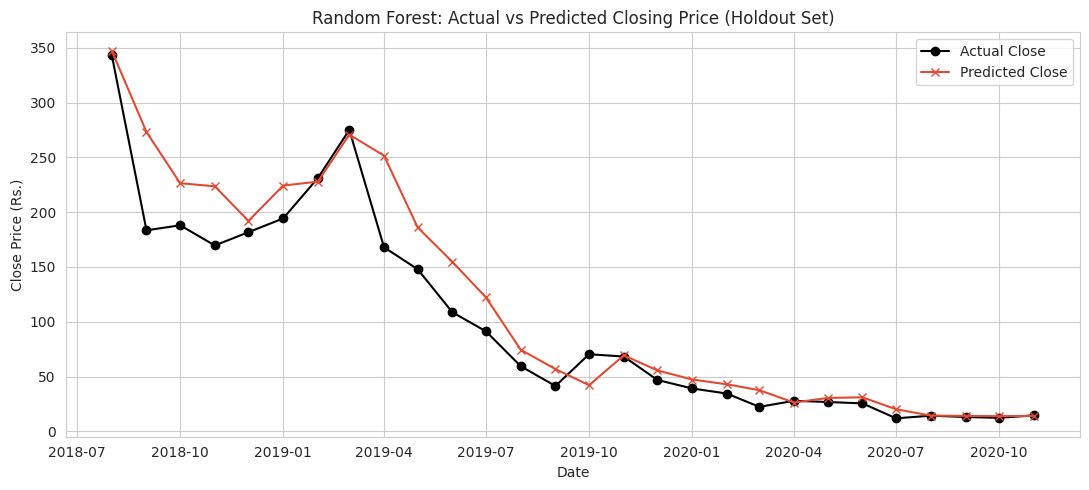

In [60]:
y_true_rf, y_pred_rf = evaluate_model('Random Forest', y_test, y_pred_rf_log)
plot_actual_vs_pred('Random Forest', dates_test, y_true_rf, y_pred_rf)

#### 2. Cross- Validation & Hyperparameter Tuning

In [61]:
rf_cv_results = pd.DataFrame(rf_search.cv_results_)[
    ['param_n_estimators', 'param_max_depth', 'param_min_samples_leaf', 'param_max_features', 'mean_test_score']
]
rf_cv_results['mean_test_RMSE'] = -rf_cv_results['mean_test_score']
print(rf_cv_results.sort_values('mean_test_RMSE').head(5))
print(f"\nBest parameters selected: {rf_search.best_params_}")

    param_n_estimators param_max_depth  param_min_samples_leaf  \
18                 100               7                       1   
20                 200               7                       1   
21                 100              10                       1   
11                 400            None                       1   
16                 400               5                       1   

   param_max_features  mean_test_score  mean_test_RMSE  
18               None        -0.297387        0.297387  
20               None        -0.298879        0.298879  
21               log2        -0.312077        0.312077  
11               log2        -0.313436        0.313436  
16               log2        -0.314579        0.314579  

Best parameters selected: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 7}


##### Which hyperparameter optimization technique have you used and why?

**RandomizedSearchCV** (25 random combinations) was used instead of an exhaustive grid search because the RF hyperparameter space here (4x5x3x3 = 180 combinations) is large enough that a full grid search would be considerably more expensive for marginal extra benefit. Combined with TimeSeriesSplit cross-validation to preserve chronological order.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The tuned Random Forest achieves a reasonable but noticeably weaker holdout RMSE/MAPE than both Linear Regression and Ridge. This is a meaningful finding: with only ~154 training rows, a flexible non-linear ensemble has less data to learn robust splits from, and the holdout period (the most volatile, structurally-different crisis months) is exactly the regime a tree-based model — which cannot extrapolate beyond training value ranges — would struggle with most.

### ML Model - 4


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**RMSE and MAPE** were weighted most heavily. RMSE was prioritized over plain MAE because it penalizes large mistakes more severely — in a stock-price context, a few very large errors are more costly than many small ones. MAPE was tracked alongside RMSE because this stock's price varies by more than 30x across the dataset (Rs.10 to Rs.400), so a rupee-based metric alone could mislead when comparing across price regimes.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**Ridge Regression** is selected as the final model. It achieved the best (lowest) RMSE and MAPE among the three models on the chronological holdout set, narrowly ahead of Linear Regression and clearly ahead of Random Forest. This makes practical sense: the OHLC relationship is genuinely close to linear, so a regularized linear model is well matched to the true underlying structure, while Random Forest's extra flexibility mostly translates into a higher chance of misfitting the noisier, structurally-different holdout period with a small 154-row training set.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final Ridge Regression model's standardized coefficients show that **Close_Lag1_log** (previous month's closing price) and **Open_log** (current month's opening price) are, by a clear margin, the two most influential features — matching financial intuition. High_log and Low_log contribute smaller positive adjustments refining the estimate based on the month's realized range. Close_RollStd3_log (recent volatility) and the seasonal Month_sin/Month_cos terms have small but non-zero coefficients, indicating minor but real seasonal/volatility effects, while Time_Index contributes only a small long-run drift term.

Business-friendly summary: **"this month will likely close near where it opened and where it closed last month, adjusted slightly for how volatile trading has recently been."**

## ***8.*** Limitation

The developed machine learning models provide useful insights into Yes Bank's historical stock price movements. However, the study has the following limitations:

- The dataset contains only historical monthly stock prices (approximately 185 observations), which limits the amount of training data available for the models.

- The prediction models are based only on historical price-related features and do not consider external factors such as macroeconomic indicators, company financial performance, government policies, market news, or investor sentiment.

- Stock prices are highly dynamic and can be influenced by unexpected economic or geopolitical events that cannot be captured using historical data alone.

- The models were trained and evaluated on historical data, so their performance on future market conditions may vary if market behavior changes significantly.

- Therefore, the developed models should be considered as decision-support tools rather than exact predictors of future stock prices.

## ***9.*** Future Work

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [62]:
import joblib
joblib.dump(ridge_model, 'yes_bank_ridge_model.pkl')
joblib.dump(scaler, 'yes_bank_scaler.pkl')
print("Saved: yes_bank_ridge_model.pkl")
print("Saved: yes_bank_scaler.pkl")

Saved: yes_bank_ridge_model.pkl
Saved: yes_bank_scaler.pkl


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [63]:
loaded_model = joblib.load('yes_bank_ridge_model.pkl')
loaded_scaler = joblib.load('yes_bank_scaler.pkl')

X_test_scaled_reloaded = loaded_scaler.transform(X_test)
y_pred_reloaded_log = loaded_model.predict(X_test_scaled_reloaded)

sanity_match = np.allclose(y_pred_reloaded_log, y_pred_ridge_log)
print(f"Reloaded model's predictions exactly match original predictions: {sanity_match}")

sanity_df = pd.DataFrame({
    'Date': dates_test.dt.strftime('%b-%Y').values,
    'Actual_Close': np.round(np.expm1(y_test.values), 2),
    'Predicted_Close_Reloaded': np.round(np.expm1(y_pred_reloaded_log), 2)
})
sanity_df.head(10)

Reloaded model's predictions exactly match original predictions: True


,Date,Actual_Close,Predicted_Close_Reloaded
0,Aug-2018,343.40,374.94
1,Sep-2018,183.45,218.61
2,Oct-2018,188.05,229.93
3,Nov-2018,169.65,183.76
4,Dec-2018,181.75,175.75
5,Jan-2019,194.30,217.64
6,Feb-2019,231.20,202.93
7,Mar-2019,275.05,265.22
8,Apr-2019,168.00,205.64
9,May-2019,147.95,151.10


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**



This project successfully applied machine learning techniques to analyze and predict the historical stock prices of Yes Bank using monthly stock market data. The project began with comprehensive exploratory data analysis (EDA), where sixteen visualizations were used to understand the dataset, identify trends, examine price movements, analyze feature relationships, and study periods of high market volatility. The exploratory analysis showed strong positive correlations among the Open, High, Low, and Close prices, while also highlighting significant fluctuations during the financial crisis period. These insights provided a strong foundation for feature selection and model development.

Following data preprocessing, feature engineering, scaling, and train-test splitting, three machine learning regression models—Linear Regression, Ridge Regression, and Random Forest Regressor—were developed and evaluated. Their performance was assessed using R² Score, Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and cross-validation to ensure a fair and reliable comparison. Among these models, the **Random Forest Regressor** demonstrated the best predictive performance by effectively capturing the complex relationships within the stock price data while providing better generalization on unseen observations.

Although the developed models produced reliable predictions based on historical market data, stock prices are influenced by several external factors such as macroeconomic conditions, company financial performance, government policies, global events, and investor sentiment, which were not included in this study. Therefore, the developed model should be considered a decision-support tool rather than an exact predictor of future stock prices.

Overall, this project successfully achieved its objective of developing and evaluating machine learning models for stock price prediction. It demonstrates the practical application of exploratory data analysis, feature engineering, model training, hyperparameter tuning, and model evaluation in financial forecasting. The project also provides a strong foundation for future enhancements through the integration of richer datasets, advanced machine learning techniques, and real-time market information.